<a href="https://colab.research.google.com/github/Faisaleka21/Machine_Learning/blob/main/Cluster_K_Means_Kresno_Farm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

sebelum diimpleentasikan, maka dilakukan lah untuk pemilihan atribut. untuk hasil dari pemilihan atribut berada di kode dibawah :

https://github.com/Faisaleka21/Machine_Learning/blob/ffaebfa78a5da7410484048926953ec8f96227e4/pemilihan_atribut_K_Means.ipynb

In [ ]:
pip install kneed

In [ ]:
# ============================================================================
# IMPORT LIBRARY
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm
import warnings
from kneed import KneeLocator
warnings.filterwarnings('ignore')

In [ ]:
# ============================================================================
# TAHAP 1. MEMUAT DATASET
# ============================================================================
print("=" * 80)
print("IMPLEMENTASI K-MEANS CLUSTERING PADA DATASET PEMESANAN OPAK GAMBIR")
print("FITUR CLUSTERING: JUMLAH, HARGA, & ISIAN")
print("=" * 80)

# Membaca dataset
df = pd.read_csv("https://raw.githubusercontent.com/Faisaleka21/Machine_Learning/refs/heads/main/data_set/kresnofarmok.csv", sep=';')
print(f"\nDataset berhasil dimuat.")
print(f"Jumlah data: {len(df)} baris")
print(f"Jumlah atribut: {len(df.columns)} kolom")
print(f"Atribut: {list(df.columns)}")

IMPLEMENTASI K-MEANS CLUSTERING PADA DATASET PEMESANAN OPAK GAMBIR
FITUR CLUSTERING: JUMLAH, HARGA, & ISIAN

Dataset berhasil dimuat.
Jumlah data: 180 baris
Jumlah atribut: 10 kolom
Atribut: ['tgl', 'jumlah', 'harga', 'isian', 'tuan', 'hiasan', 'stiker', 'warna', 'dp', 'ongkir']


In [ ]:
# ============================================================================
# TAHAP 2. MENAMPILKAN INFORMASI DATASET DAN STATISTIK DESKRIPTIF
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 2. INFORMASI DATASET DAN STATISTIK DESKRIPTIF")
print("=" * 80)

# Tampilkan 10 data pertama
print("\n10 Data Pertama:")
print(df.head(10).to_string())

# Informasi dataset
print(f"\nInformasi Dataset:")
print(f"  Jumlah baris : {df.shape[0]}")
print(f"  Jumlah kolom : {df.shape[1]}")

# Cek nilai unik isian sebelum konversi
print(f"\nNilai unik pada atribut 'isian':")
print(f"  {df['isian'].unique()}")
print(f"  Jumlah nilai unik: {df['isian'].nunique()}")

# Statistik deskriptif untuk jumlah, harga, dan isian
print(f"\nStatistik Deskriptif Atribut 'jumlah', 'harga', dan 'isian':")
print(df[['jumlah', 'harga', 'isian']].describe().to_string())

# Cek missing value
print(f"\nMissing Value:")
for col in ['jumlah', 'harga', 'isian']:
    print(f"  {col}: {df[col].isnull().sum()} missing")

# Informasi tipe data
print(f"\nTipe Data:")
for col in ['jumlah', 'harga', 'isian']:
    print(f"  {col}: {df[col].dtype}")



TAHAP 2. INFORMASI DATASET DAN STATISTIK DESKRIPTIF

10 Data Pertama:
          tgl  jumlah  harga  isian tuan      hiasan  stiker     warna   dp   ongkir
0  20/01/2025     900   6000   28.0    x        tali  kresno  campuran           NaN
1  05/01/2025     500   6500    NaN    e       paper  kresno  campuran  NaN      NaN
2  05/01/2025     100   8500    NaN    e       paper  kresno  campuran  NaN      NaN
3  05/01/2025      60   6000    NaN    t       paper  kresno  campuran  NaN      NaN
4  13/01/2025     450   6500    NaN    s       paper  kresno  campuran  NaN      NaN
5  15/01/2025     900   5000    NaN    a  tanpa pita  kresno  campuran  NaN      NaN
6  15/01/2025     350   8000   28.0    q       kipas  kresno  campuran  NaN  50000.0
7  04/01/2025     600   6500    NaN    w       paper  kresno   2 warna  NaN      NaN
8  15/01/2025     750   6000    NaN    e        tali  kresno  campuran  NaN      NaN
9  16/01/2025     700   6500    NaN    t       paper  kresno  campuran  NaN    

In [ ]:
# ============================================================================
# TAHAP 3. MENANGANI MISSING VALUE DAN KONVERSI ISIAN
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 3. MENANGANI MISSING VALUE DAN KONVERSI ISIAN")
print("=" * 80)

# Konversi isian ke numerik (sama seperti jumlah dan harga)
# Isian yang berupa string/karakter akan diubah menjadi NaN, lalu diisi
df['isian'] = pd.to_numeric(df['isian'], errors='coerce')
print(f"Setelah konversi ke numerik:")
print(f"  Missing value pada isian: {df['isian'].isnull().sum()}")

# Tangani missing value untuk ketiga fitur
for col in ['jumlah', 'harga', 'isian']:
    missing_before = df[col].isnull().sum()
    if missing_before > 0:
        # Isi dengan median (lebih robust terhadap outlier)
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  {col}: {missing_before} missing value diisi dengan median ({median_val:.2f})")
    else:
        print(f"  {col}: Tidak ada missing value")

# Verifikasi tidak ada missing value tersisa
print(f"\nMissing value setelah penanganan:")
for col in ['jumlah', 'harga', 'isian']:
    print(f"  {col}: {df[col].isnull().sum()} missing")

print(f"\nStatistik isian setelah konversi:")
print(f"  Min: {df['isian'].min():.0f}")
print(f"  Max: {df['isian'].max():.0f}")
print(f"  Mean: {df['isian'].mean():.2f}")
print(f"  Median: {df['isian'].median():.0f}")
print(f"  Nilai unik: {df['isian'].nunique()}")



TAHAP 3. MENANGANI MISSING VALUE DAN KONVERSI ISIAN
Setelah konversi ke numerik:
  Missing value pada isian: 76
  jumlah: Tidak ada missing value
  harga: Tidak ada missing value
  isian: 76 missing value diisi dengan median (23.00)

Missing value setelah penanganan:
  jumlah: 0 missing
  harga: 0 missing
  isian: 0 missing

Statistik isian setelah konversi:
  Min: 15
  Max: 35
  Mean: 23.69
  Median: 23
  Nilai unik: 5


In [ ]:
# ============================================================================
# TAHAP 4. EKSTRAKSI FITUR DAN NORMALISASI DATA
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 4. EKSTRAKSI FITUR DAN NORMALISASI DATA (MinMaxScaler)")
print("=" * 80)

# Ekstraksi fitur jumlah, harga, dan isian
X = df[['jumlah', 'harga', 'isian']].values

print(f"Dimensi data sebelum normalisasi: {X.shape}")
print(f"Range jumlah sebelum normalisasi: {X[:, 0].min():.0f} - {X[:, 0].max():.0f}")
print(f"Range harga sebelum normalisasi : {X[:, 1].min():.0f} - {X[:, 1].max():.0f}")
print(f"Range isian sebelum normalisasi : {X[:, 2].min():.0f} - {X[:, 2].max():.0f}")

# Normalisasi menggunakan MinMaxScaler
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

print(f"\nRange setelah normalisasi:")
print(f"  Jumlah: {X_normalized[:, 0].min():.4f} - {X_normalized[:, 0].max():.4f}")
print(f"  Harga : {X_normalized[:, 1].min():.4f} - {X_normalized[:, 1].max():.4f}")
print(f"  Isian : {X_normalized[:, 2].min():.4f} - {X_normalized[:, 2].max():.4f}")

# Tampilkan 5 data pertama setelah normalisasi
print(f"\n5 data pertama setelah normalisasi:")
norm_df = pd.DataFrame(X_normalized[:5], columns=['jumlah', 'harga', 'isian'])
print(norm_df.round(4).to_string())



TAHAP 4. EKSTRAKSI FITUR DAN NORMALISASI DATA (MinMaxScaler)
Dimensi data sebelum normalisasi: (180, 3)
Range jumlah sebelum normalisasi: 1 - 8500
Range harga sebelum normalisasi : 600 - 17000
Range isian sebelum normalisasi : 15 - 35

Range setelah normalisasi:
  Jumlah: 0.0000 - 1.0000
  Harga : 0.0000 - 1.0000
  Isian : 0.0000 - 1.0000

5 data pertama setelah normalisasi:
   jumlah   harga  isian
0  0.1058  0.3293   0.65
1  0.0587  0.3598   0.40
2  0.0116  0.4817   0.40
3  0.0069  0.3293   0.40
4  0.0528  0.3598   0.40



TAHAP 5. MENENTUKAN JUMLAH CLUSTER OPTIMAL
Metode: Elbow Method & Silhouette Score
  K=2: Inertia=8.9786, Silhouette Score=0.4992
  K=3: Inertia=5.6500, Silhouette Score=0.6140
  K=4: Inertia=3.7579, Silhouette Score=0.6622
  K=5: Inertia=2.1980, Silhouette Score=0.6955
  K=6: Inertia=1.3671, Silhouette Score=0.7150
  K=7: Inertia=1.0680, Silhouette Score=0.6519
  K=8: Inertia=0.8070, Silhouette Score=0.6545
  K=9: Inertia=0.6074, Silhouette Score=0.6641
  K=10: Inertia=0.4524, Silhouette Score=0.6570


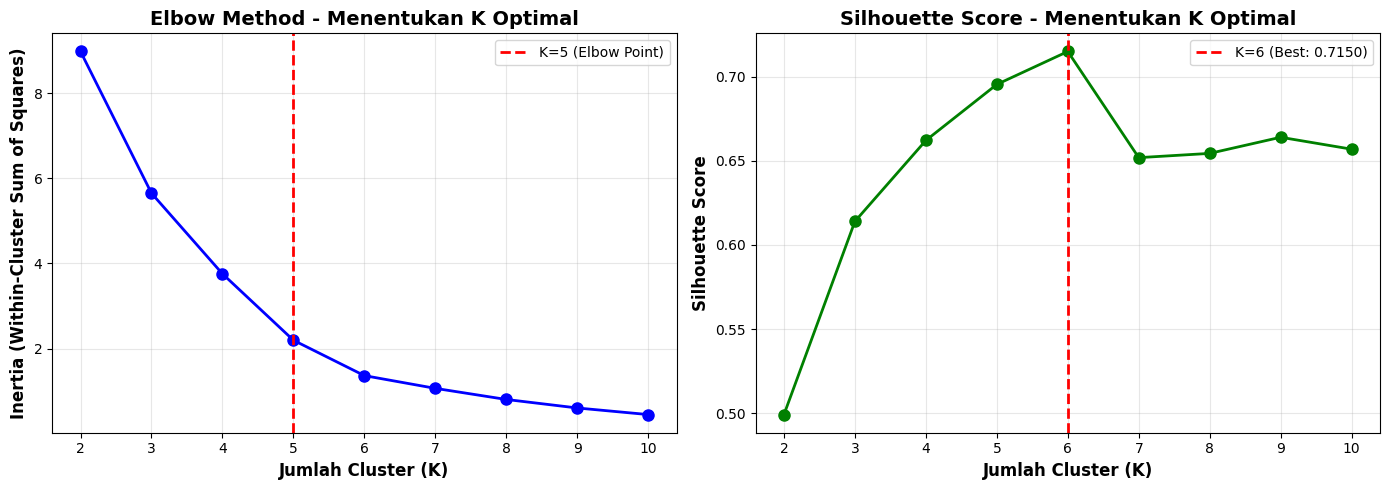

In [ ]:
# ============================================================================
# TAHAP 5. MENENTUKAN JUMLAH CLUSTER OPTIMAL (ELBOW & SILHOUETTE)
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 5. MENENTUKAN JUMLAH CLUSTER OPTIMAL")
print("=" * 80)
print("Metode: Elbow Method & Silhouette Score")

# Uji K dari 2 sampai 10
K_range = range(2, 11)
inertia_values = []
silhouette_values = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_normalized)
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_normalized, labels))
    print(f"  K={k}: Inertia={kmeans.inertia_:.4f}, Silhouette Score={silhouette_values[-1]:.4f}")

# Visualisasi Elbow Method dan Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Menentukan elbow otomatis
knee = KneeLocator(
    list(K_range),
    inertia_values,
    curve='convex',
    direction='decreasing'
)
best_k_elbow = knee.elbow


# Plot Elbow manual
axes[0].plot(K_range, inertia_values, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Cluster (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method - Menentukan K Optimal', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=best_k_elbow, color='red', linestyle='--', linewidth=2, label=f'K={best_k_elbow} (Elbow Point)')
axes[0].legend()

# Plot Silhouette Score
axes[1].plot(K_range, silhouette_values, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Cluster (K)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette Score - Menentukan K Optimal', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
best_k_sil = K_range[np.argmax(silhouette_values)]
best_sil = max(silhouette_values)
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', linewidth=2,
                label=f'K={best_k_sil} (Best: {best_sil:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette_3fitur.png', dpi=150, bbox_inches='tight')
plt.show()

# # Tentukan K optimal
# best_k = 3  # Sesuai kebutuhan penelitian: Tinggi, Sedang, Rendah
# print(f"\n>>> JUMLAH CLUSTER OPTIMAL: K = {best_k} <<<")
# print(f"Alasan pemilihan K={best_k}:")
# print(f"  1. Sesuai tujuan penelitian: mengelompokkan menjadi 3 kategori")
# print(f"     (Pemesanan Tinggi, Sedang, Rendah)")
# if best_k == best_k_sil:
#     print(f"  2. Silhouette Score tertinggi pada K={best_k}")
# print(f"  3. Terlihat elbow point pada K={best_k} di Elbow Method")

In [ ]:
# ============================================================================
# TAHAP 6. MENERAPKAN ALGORITMA K-MEANS (K=3)
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 6. MENERAPKAN ALGORITMA K-MEANS (K=3)")
print("=" * 80)

# Terapkan K-Means dengan K=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_normalized)

print("K-Means clustering berhasil diterapkan.")
print(f"Jumlah iterasi: {kmeans_final.n_iter_}")


TAHAP 6. MENERAPKAN ALGORITMA K-MEANS (K=3)
K-Means clustering berhasil diterapkan.
Jumlah iterasi: 3


In [ ]:
# ============================================================================
# TAHAP 7. MENAMPILKAN NILAI CENTROID SETIAP CLUSTER (DALAM TABEL)
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 7. NILAI CENTROID SETIAP CLUSTER")
print("=" * 80)

# Centroid normalisasi
centroids_normalized = kmeans_final.cluster_centers_

df_centroid_norm = pd.DataFrame(
    centroids_normalized,
    columns=["jumlah", "harga", "isian"]
)
df_centroid_norm.index = [f"Cluster {i}" for i in range(len(df_centroid_norm))]

print("\nCentroid (skala normalisasi 0-1):")
print(df_centroid_norm.round(4).to_string())

# Centroid skala asli
centroids_original = scaler.inverse_transform(centroids_normalized)

df_centroid_orig = pd.DataFrame(
    centroids_original,
    columns=["jumlah (pcs)", "harga (Rp)", "isian"]
)
df_centroid_orig.index = [f"Cluster {i}" for i in range(len(df_centroid_orig))]

df_centroid_orig["jumlah (pcs)"] = df_centroid_orig["jumlah (pcs)"].round(0).astype(int)
df_centroid_orig["harga (Rp)"] = df_centroid_orig["harga (Rp)"].round(0).astype(int)
df_centroid_orig["isian"] = df_centroid_orig["isian"].round(2).astype(int)

print("\nCentroid (skala asli):")
print(df_centroid_orig.to_string())


TAHAP 7. NILAI CENTROID SETIAP CLUSTER

Centroid (skala normalisasi 0-1):
           jumlah   harga   isian
Cluster 0  0.0805  0.4485  0.7941
Cluster 1  0.0324  0.2361  0.0000
Cluster 2  0.0569  0.3951  0.4000

Centroid (skala asli):
           jumlah (pcs)  harga (Rp)  isian
Cluster 0           685        7956     30
Cluster 1           276        4472     15
Cluster 2           485        7080     23


In [ ]:
# ============================================================================
# TAHAP 8. JUMLAH ANGGOTA SETIAP CLUSTER
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 8. JUMLAH ANGGOTA SETIAP CLUSTER")
print("=" * 80)

distribusi = df['cluster'].value_counts().sort_index()
print(f"\n{'Cluster':<10} {'Jumlah Anggota':<18} {'Persentase':<12}")
print("-" * 40)
for cluster_id in sorted(distribusi.index):
    jumlah_anggota = distribusi[cluster_id]
    persentase = (jumlah_anggota / len(df)) * 100
    print(f"Cluster {cluster_id:<3} {jumlah_anggota:<18} {persentase:.1f}%")
print("-" * 40)
print(f"{'Total':<10} {len(df):<18} 100.0%")


TAHAP 8. JUMLAH ANGGOTA SETIAP CLUSTER

Cluster    Jumlah Anggota     Persentase  
----------------------------------------
Cluster 0   34                 18.9%
Cluster 1   18                 10.0%
Cluster 2   128                71.1%
----------------------------------------
Total      180                100.0%


In [ ]:
# ============================================================================
# TAHAP 9. ANALISIS KARAKTERISTIK CLUSTER
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 9. ANALISIS KARAKTERISTIK CLUSTER")
print("=" * 80)

# Hitung statistik per cluster (termasuk isian)
cluster_stats = {}
for cluster_id in sorted(df['cluster'].unique()):
    data_cluster = df[df['cluster'] == cluster_id]
    cluster_stats[cluster_id] = {
        'count': len(data_cluster),
        'mean_jumlah': data_cluster['jumlah'].mean(),
        'median_jumlah': data_cluster['jumlah'].median(),
        'min_jumlah': data_cluster['jumlah'].min(),
        'max_jumlah': data_cluster['jumlah'].max(),
        'std_jumlah': data_cluster['jumlah'].std(),
        'mean_harga': data_cluster['harga'].mean(),
        'min_harga': data_cluster['harga'].min(),
        'max_harga': data_cluster['harga'].max(),
        'mean_isian': data_cluster['isian'].mean(),
        'min_isian': data_cluster['isian'].min(),
        'max_isian': data_cluster['isian'].max(),
        'std_isian': data_cluster['isian'].std()
    }

# Tampilkan statistik per cluster
print(f"\n{'Cluster':<10} {'Count':<8} {'Mean Jml':<12} {'Min Jml':<10} {'Max Jml':<10} {'Mean Harga':<15} {'Mean Isian':<12} {'Range Isian':<15}")
print("-" * 100)
for cluster_id in sorted(df['cluster'].unique()):
    s = cluster_stats[cluster_id]
    range_isian = f"{s['min_isian']:.0f}-{s['max_isian']:.0f}"
    print(f"Cluster {cluster_id:<3} {s['count']:<8} {s['mean_jumlah']:<12.0f} {s['min_jumlah']:<10.0f} "
          f"{s['max_jumlah']:<10.0f} Rp {s['mean_harga']:<13,.0f} {s['mean_isian']:<12.0f} {range_isian:<15}")


TAHAP 9. ANALISIS KARAKTERISTIK CLUSTER

Cluster    Count    Mean Jml     Min Jml    Max Jml    Mean Harga      Mean Isian   Range Isian    
----------------------------------------------------------------------------------------------------
Cluster 0   34       685          50         8500       Rp 7,956         31           28-35          
Cluster 1   18       276          50         800        Rp 4,472         15           15-15          
Cluster 2   128      485          1          6500       Rp 7,080         23           23-23          


In [ ]:
# ============================================================================
# TAHAP 10. INTERPRETASI DAN LABEL CLUSTER
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 10. INTERPRETASI DAN LABEL CLUSTER")
print("=" * 80)

# Urutkan cluster berdasarkan mean_jumlah (TERBESAR → TERKECIL)
sorted_clusters = sorted(cluster_stats.items(),
                         key=lambda x: x[1]['mean_jumlah'],
                         reverse=True)

label_mapping = {}

for rank, (cluster_id, stats) in enumerate(sorted_clusters):
    if rank == 0:
        label = "PEMESANAN TINGGI"
        deskripsi = (f"Cluster dengan volume pemesanan tertinggi. "
                    f"Rata-rata {stats['mean_jumlah']:.0f} pcs/transaksi, "
                    f"harga rata-rata Rp {stats['mean_harga']:,.0f}, "
                    f"isian rata-rata {stats['mean_isian']:.2f}.")
    elif rank == 1:
        label = "PEMESANAN SEDANG"
        deskripsi = (f"Cluster dengan volume pemesanan menengah. "
                    f"Rata-rata {stats['mean_jumlah']:.0f} pcs/transaksi, "
                    f"harga rata-rata Rp {stats['mean_harga']:,.0f}, "
                    f"isian rata-rata {stats['mean_isian']:.2f}.")
    else:
        label = "PEMESANAN RENDAH"
        deskripsi = (f"Cluster dengan volume pemesanan terendah. "
                    f"Rata-rata {stats['mean_jumlah']:.0f} pcs/transaksi, "
                    f"harga rata-rata Rp {stats['mean_harga']:,.0f}, "
                    f"isian rata-rata {stats['mean_isian']:.2f}.")

    label_mapping[cluster_id] = label

    print(f"\nCluster {cluster_id}: {label}")
    print(f"  {deskripsi}")
    print(f"  Range pemesanan : {stats['min_jumlah']:.0f} - {stats['max_jumlah']:.0f} pcs")
    print(f"  Standar deviasi : {stats['std_jumlah']:.0f} pcs")
    print(f"  Range harga     : Rp {stats['min_harga']:,.0f} - Rp {stats['max_harga']:,.0f}")
    print(f"  Range isian     : {stats['min_isian']:.0f} - {stats['max_isian']:.0f}")
    print(f"  Estimasi kebutuhan produksi isian: {stats['mean_jumlah'] * stats['mean_isian']:.0f} unit per transaksi")


TAHAP 10. INTERPRETASI DAN LABEL CLUSTER

Cluster 0: PEMESANAN TINGGI
  Cluster dengan volume pemesanan tertinggi. Rata-rata 685 pcs/transaksi, harga rata-rata Rp 7,956, isian rata-rata 30.88.
  Range pemesanan : 50 - 8500 pcs
  Standar deviasi : 1440 pcs
  Range harga     : Rp 6,000 - Rp 9,000
  Range isian     : 28 - 35
  Estimasi kebutuhan produksi isian: 21163 unit per transaksi

Cluster 2: PEMESANAN SEDANG
  Cluster dengan volume pemesanan menengah. Rata-rata 485 pcs/transaksi, harga rata-rata Rp 7,080, isian rata-rata 23.00.
  Range pemesanan : 1 - 6500 pcs
  Standar deviasi : 809 pcs
  Range harga     : Rp 600 - Rp 17,000
  Range isian     : 23 - 23
  Estimasi kebutuhan produksi isian: 11148 unit per transaksi

Cluster 1: PEMESANAN RENDAH
  Cluster dengan volume pemesanan terendah. Rata-rata 276 pcs/transaksi, harga rata-rata Rp 4,472, isian rata-rata 15.00.
  Range pemesanan : 50 - 800 pcs
  Standar deviasi : 220 pcs
  Range harga     : Rp 4,000 - Rp 4,500
  Range isian     : 

In [ ]:
# ============================================================================
# TAHAP 11. MENGHITUNG SILHOUETTE SCORE AKHIR
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 11. SILHOUETTE SCORE AKHIR")
print("=" * 80)

silhouette_final = silhouette_score(X_normalized, df['cluster'])
silhouette_samples_final = silhouette_samples(X_normalized, df['cluster'])

print(f"\nSilhouette Score (K=3): {silhouette_final:.4f}")
print(f"Range Silhouette Score: -1 (buruk) hingga 1 (sempurna)")

if silhouette_final > 0.5:
    interpretasi = "BAIK - Cluster terpisah dengan jelas (well-separated)"
elif silhouette_final > 0.25:
    interpretasi = "CUKUP BAIK - Ada sedikit tumpang tindih antar cluster"
elif silhouette_final > 0:
    interpretasi = "KURANG BAIK - Cluster saling tumpang tindih"
else:
    interpretasi = "BURUK - Banyak data mungkin salah cluster"

print(f"Interpretasi: {interpretasi}")

# Silhouette per cluster
print(f"\nSilhouette Score per Cluster:")
for i in range(3):
    cluster_sil = silhouette_samples_final[df['cluster'] == i]
    print(f"  {label_mapping[i]} (Cluster {i}): {np.mean(cluster_sil):.4f}")


TAHAP 11. SILHOUETTE SCORE AKHIR

Silhouette Score (K=3): 0.6140
Range Silhouette Score: -1 (buruk) hingga 1 (sempurna)
Interpretasi: BAIK - Cluster terpisah dengan jelas (well-separated)

Silhouette Score per Cluster:
  PEMESANAN TINGGI (Cluster 0): 0.4165
  PEMESANAN RENDAH (Cluster 1): 0.9339
  PEMESANAN SEDANG (Cluster 2): 0.6215



TAHAP 12. VISUALISASI HASIL CLUSTERING (3D dan 2D)


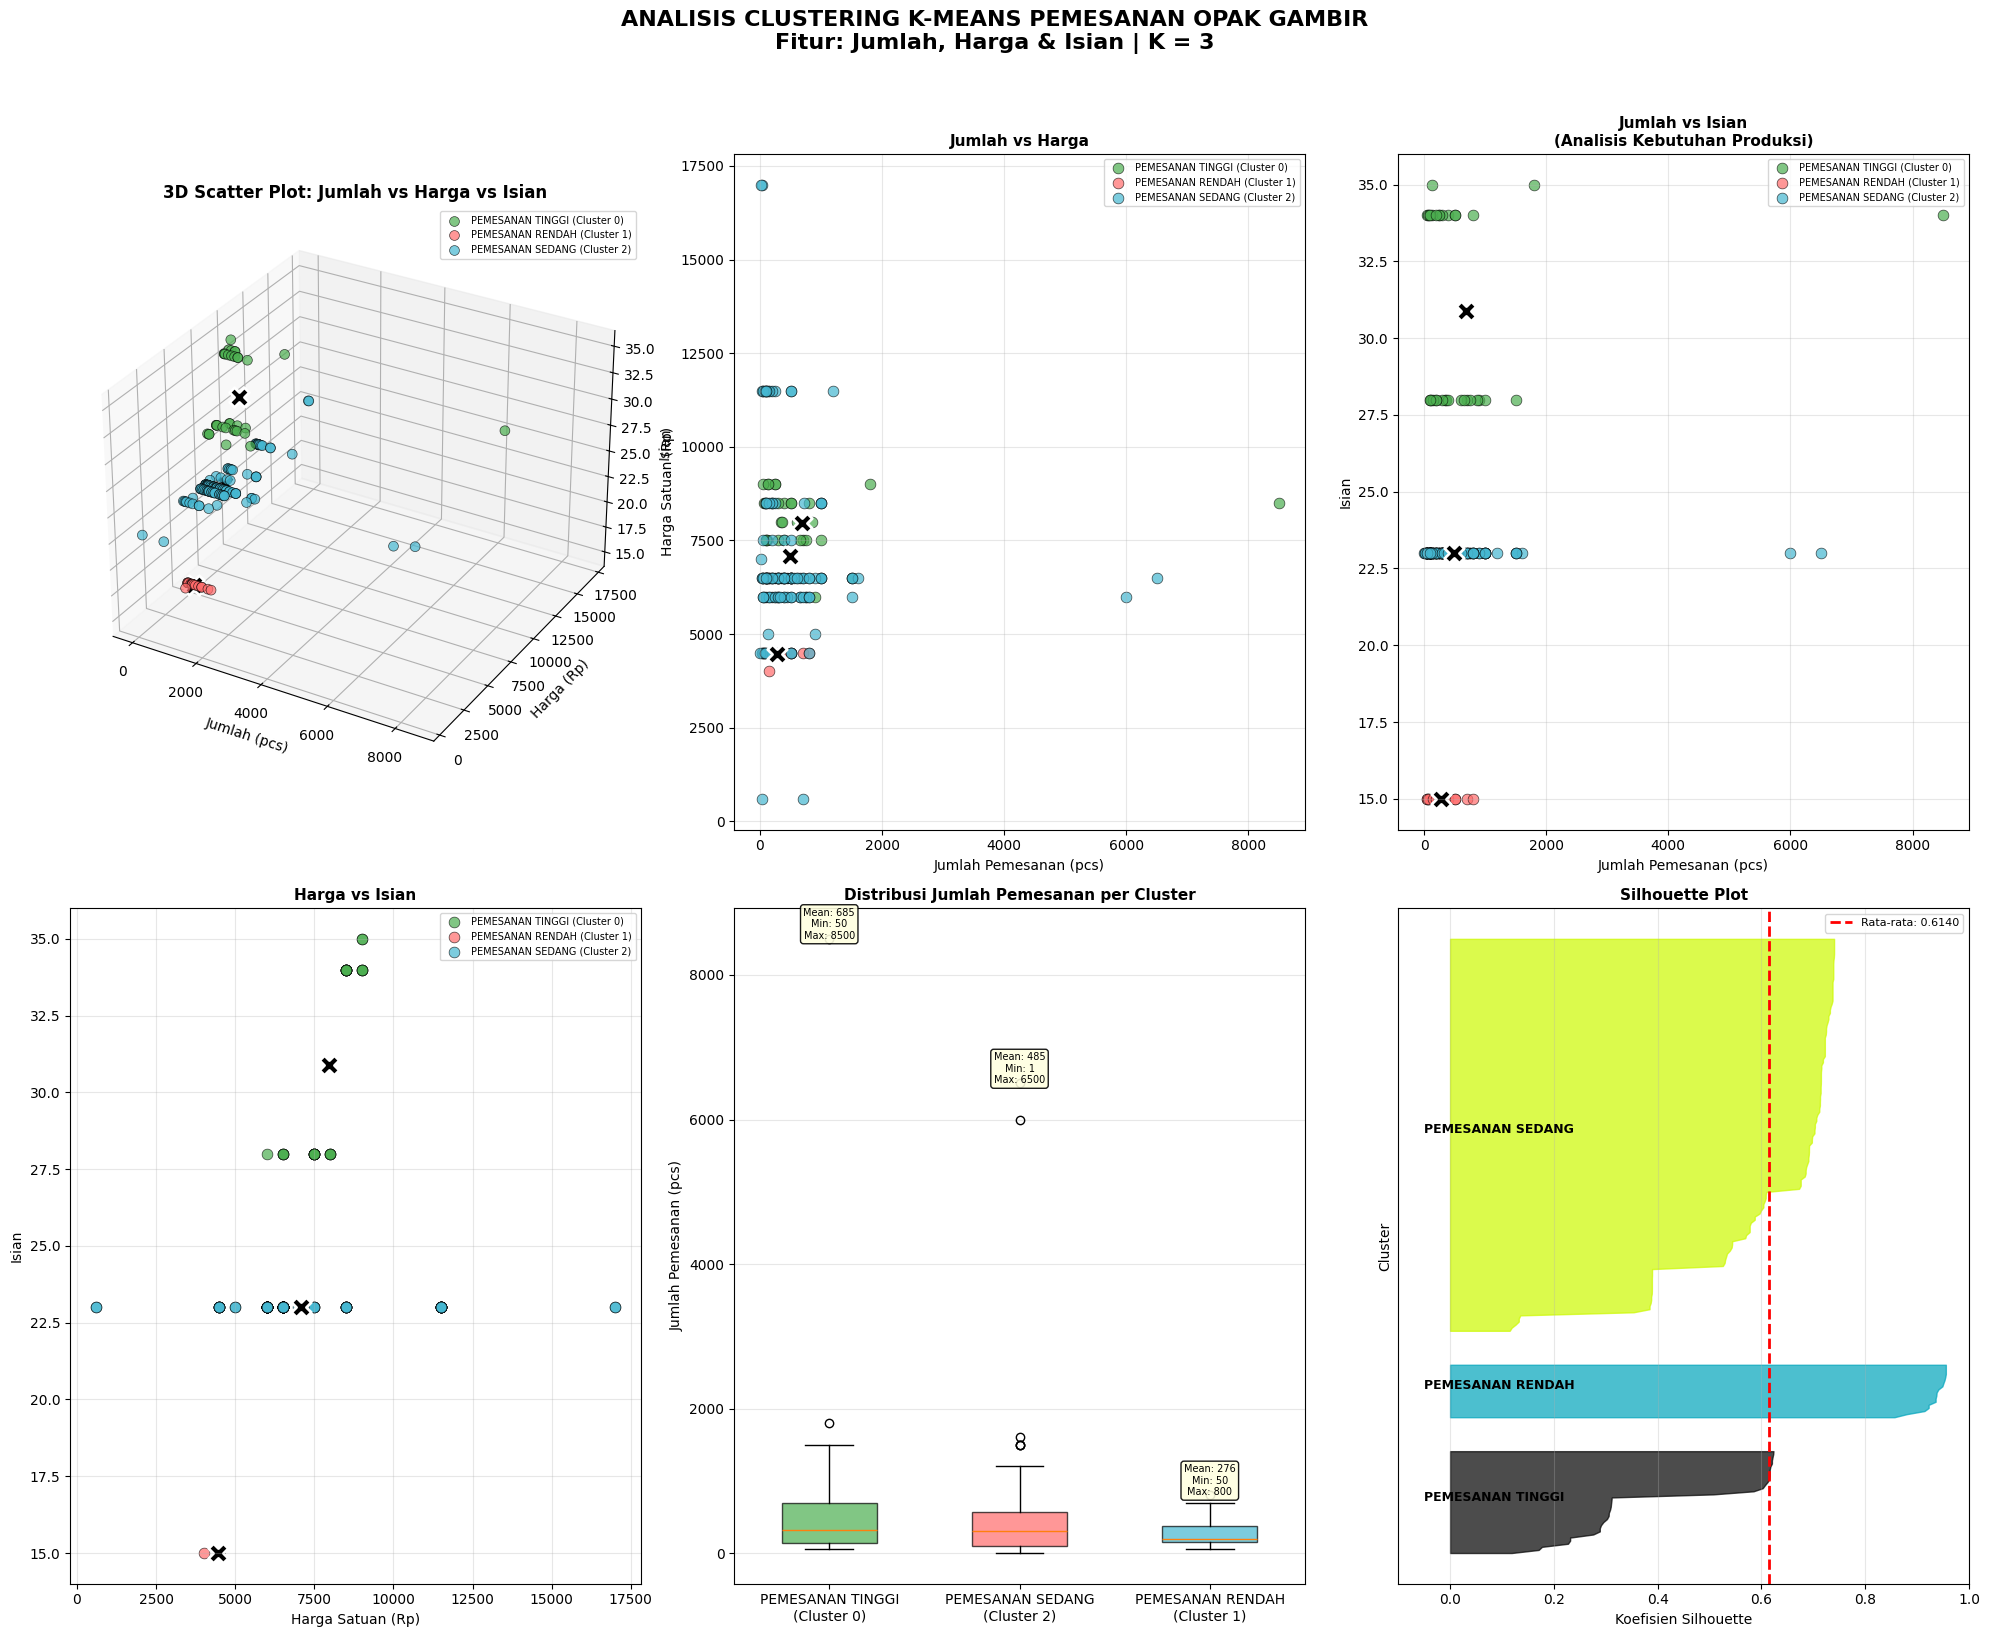

Visualisasi hasil clustering berhasil dibuat.


In [ ]:
# ============================================================================
# TAHAP 12. VISUALISASI HASIL CLUSTERING
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 12. VISUALISASI HASIL CLUSTERING (3D dan 2D)")
print("=" * 80)

# Warna untuk setiap cluster
warna_cluster = ['#4CAF50', '#FF6B6B', '#45B7D1']

# Buat figure
fig = plt.figure(figsize=(20, 16))

# --- SUBPLOT 1: 3D Scatter Plot ---
from mpl_toolkits.mplot3d import Axes3D
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
for i, cluster_id in enumerate(sorted(df['cluster'].unique())):
    mask = df['cluster'] == cluster_id
    ax1.scatter(df.loc[mask, 'jumlah'], df.loc[mask, 'harga'], df.loc[mask, 'isian'],
               c=warna_cluster[i], label=f"{label_mapping[cluster_id]} (Cluster {cluster_id})",
               alpha=0.7, edgecolors='black', linewidth=0.5, s=50)

# Plot centroid dalam skala asli
for i in range(3):
    ax1.scatter(centroids_original[i, 0], centroids_original[i, 1], centroids_original[i, 2],
               c='black', marker='X', s=200, edgecolors='white', linewidth=2)

ax1.set_xlabel('Jumlah (pcs)', fontsize=10)
ax1.set_ylabel('Harga (Rp)', fontsize=10)
ax1.set_zlabel('Isian', fontsize=10)
ax1.set_title('3D Scatter Plot: Jumlah vs Harga vs Isian', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=7)

# --- SUBPLOT 2: Jumlah vs Harga (Data Asli) ---
ax2 = fig.add_subplot(2, 3, 2)
for i, cluster_id in enumerate(sorted(df['cluster'].unique())):
    mask = df['cluster'] == cluster_id
    ax2.scatter(df.loc[mask, 'jumlah'], df.loc[mask, 'harga'],
               c=warna_cluster[i], label=f"{label_mapping[cluster_id]} (Cluster {cluster_id})",
               alpha=0.7, edgecolors='black', linewidth=0.5, s=60)

for i in range(3):
    ax2.scatter(centroids_original[i, 0], centroids_original[i, 1],
               c='black', marker='X', s=200, edgecolors='white', linewidth=2)

ax2.set_xlabel('Jumlah Pemesanan (pcs)', fontsize=10)
ax2.set_ylabel('Harga Satuan (Rp)', fontsize=10)
ax2.set_title('Jumlah vs Harga', fontsize=11, fontweight='bold')
ax2.legend(loc='best', fontsize=7)
ax2.grid(alpha=0.3)

# --- SUBPLOT 3: Jumlah vs Isian ---
ax3 = fig.add_subplot(2, 3, 3)
for i, cluster_id in enumerate(sorted(df['cluster'].unique())):
    mask = df['cluster'] == cluster_id
    ax3.scatter(df.loc[mask, 'jumlah'], df.loc[mask, 'isian'],
               c=warna_cluster[i], label=f"{label_mapping[cluster_id]} (Cluster {cluster_id})",
               alpha=0.7, edgecolors='black', linewidth=0.5, s=60)

for i in range(3):
    ax3.scatter(centroids_original[i, 0], centroids_original[i, 2],
               c='black', marker='X', s=200, edgecolors='white', linewidth=2)

ax3.set_xlabel('Jumlah Pemesanan (pcs)', fontsize=10)
ax3.set_ylabel('Isian', fontsize=10)
ax3.set_title('Jumlah vs Isian\n(Analisis Kebutuhan Produksi)', fontsize=11, fontweight='bold')
ax3.legend(loc='best', fontsize=7)
ax3.grid(alpha=0.3)

# --- SUBPLOT 4: Harga vs Isian ---
ax4 = fig.add_subplot(2, 3, 4)
for i, cluster_id in enumerate(sorted(df['cluster'].unique())):
    mask = df['cluster'] == cluster_id
    ax4.scatter(df.loc[mask, 'harga'], df.loc[mask, 'isian'],
               c=warna_cluster[i], label=f"{label_mapping[cluster_id]} (Cluster {cluster_id})",
               alpha=0.7, edgecolors='black', linewidth=0.5, s=60)

for i in range(3):
    ax4.scatter(centroids_original[i, 1], centroids_original[i, 2],
               c='black', marker='X', s=200, edgecolors='white', linewidth=2)

ax4.set_xlabel('Harga Satuan (Rp)', fontsize=10)
ax4.set_ylabel('Isian', fontsize=10)
ax4.set_title('Harga vs Isian', fontsize=11, fontweight='bold')
ax4.legend(loc='best', fontsize=7)
ax4.grid(alpha=0.3)

# --- SUBPLOT 5: Boxplot Jumlah per Cluster ---
ax5 = fig.add_subplot(2, 3, 5)
cluster_order = sorted(df['cluster'].unique(),
                       key=lambda x: cluster_stats[x]['mean_jumlah'],
                       reverse=True)
data_box = [df[df['cluster'] == c]['jumlah'].values for c in cluster_order]
label_box = [f'{label_mapping[c]}\n(Cluster {c})' for c in cluster_order]

bp = ax5.boxplot(data_box, labels=label_box, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], warna_cluster):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax5.set_title('Distribusi Jumlah Pemesanan per Cluster', fontsize=11, fontweight='bold')
ax5.set_ylabel('Jumlah Pemesanan (pcs)', fontsize=10)
ax5.grid(axis='y', alpha=0.3)

for i, c in enumerate(cluster_order):
    s = cluster_stats[c]
    ax5.annotate(f"Mean: {s['mean_jumlah']:.0f}\nMin: {s['min_jumlah']:.0f}\nMax: {s['max_jumlah']:.0f}",
                xy=(i+1, s['max_jumlah']), fontsize=7, ha='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# --- SUBPLOT 6: Silhouette Plot ---
ax6 = fig.add_subplot(2, 3, 6)
y_lower = 10
for i in range(3):
    ith_cluster_sil = silhouette_samples_final[df['cluster'] == i]
    ith_cluster_sil.sort()
    size_cluster_i = len(ith_cluster_sil)
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / 3)
    ax6.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax6.text(-0.05, y_lower + 0.5 * size_cluster_i,
             f'{label_mapping[i]}', fontsize=9, fontweight='bold')
    y_lower = y_upper + 10

ax6.axvline(x=silhouette_final, color="red", linestyle="--", linewidth=2,
            label=f'Rata-rata: {silhouette_final:.4f}')
ax6.set_title('Silhouette Plot', fontsize=11, fontweight='bold')
ax6.set_xlabel('Koefisien Silhouette', fontsize=10)
ax6.set_ylabel('Cluster', fontsize=10)
ax6.set_yticks([])
ax6.set_xlim([-0.1, 1])
ax6.legend(loc='best', fontsize=8)
ax6.grid(axis='x', alpha=0.3)

plt.suptitle('ANALISIS CLUSTERING K-MEANS PEMESANAN OPAK GAMBIR\nFitur: Jumlah, Harga & Isian | K = 3',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hasil_clustering_3fitur.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualisasi hasil clustering berhasil dibuat.")

In [ ]:
# ============================================================================
# TAHAP 13. TABEL RINGKASAN CLUSTER
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 13. TABEL RINGKASAN CLUSTER")
print("=" * 80)

print("\n" + "=" * 120)
print("TABEL RINGKASAN KARAKTERISTIK CLUSTER PEMESANAN OPAK GAMBIR")
print("=" * 120)
print(f"{'Nama Cluster':<22} {'Jumlah':<8} {'Rata² Jml':<12} {'Range Jml':<18} {'Rata² Harga':<15} {'Rata² Isian':<12} {'Range Isian':<15}")
print("-" * 120)

for cluster_id, stats in sorted_clusters:
    s = cluster_stats[cluster_id]
    range_jml = f"{s['min_jumlah']:.0f}-{s['max_jumlah']:.0f} pcs"
    range_isian = f"{s['min_isian']:.0f}-{s['max_isian']:.0f}"
    print(f"{label_mapping[cluster_id]:<22} {s['count']:<8} {s['mean_jumlah']:<12.0f} {range_jml:<18} "
          f"Rp {s['mean_harga']:<13,.0f} {s['mean_isian']:<12.2f} {range_isian:<15}")

print("=" * 120)


TAHAP 13. TABEL RINGKASAN CLUSTER

TABEL RINGKASAN KARAKTERISTIK CLUSTER PEMESANAN OPAK GAMBIR
Nama Cluster           Jumlah   Rata² Jml    Range Jml          Rata² Harga     Rata² Isian  Range Isian    
------------------------------------------------------------------------------------------------------------------------
PEMESANAN TINGGI       34       685          50-8500 pcs        Rp 7,956         30.88        28-35          
PEMESANAN SEDANG       128      485          1-6500 pcs         Rp 7,080         23.00        23-23          
PEMESANAN RENDAH       18       276          50-800 pcs         Rp 4,472         15.00        15-15          



TAHAP 14. VISUALISASI DISTRIBUSI CLUSTER (PIE CHART)


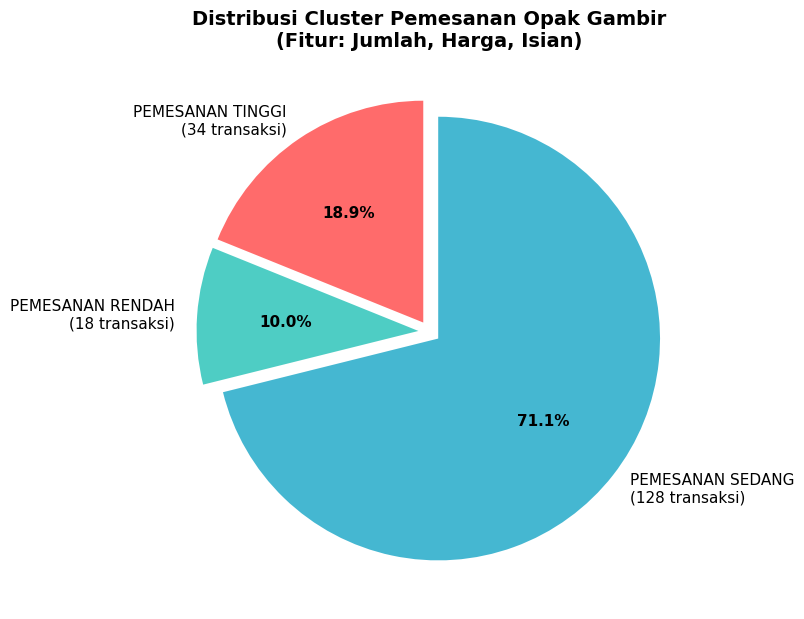

Pie chart distribusi cluster berhasil dibuat.


In [ ]:
# ============================================================================
# TAHAP 14. VISUALISASI PIE CHART DISTRIBUSI
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 14. VISUALISASI DISTRIBUSI CLUSTER (PIE CHART)")
print("=" * 80)

fig, ax = plt.subplots(figsize=(8, 8))
sizes = [cluster_stats[c]['count'] for c in sorted(df['cluster'].unique())]
labels = [f'{label_mapping[c]}\n({sizes[i]} transaksi)' for i, c in enumerate(sorted(df['cluster'].unique()))]
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1']
explode = (0.05, 0.05, 0.05)

wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors_pie,
                                   autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_fontweight('bold')

ax.set_title('Distribusi Cluster Pemesanan Opak Gambir\n(Fitur: Jumlah, Harga, Isian)',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pie_chart_cluster_3fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print("Pie chart distribusi cluster berhasil dibuat.")

In [ ]:
# ============================================================================
# TAHAP 15. KESIMPULAN AKHIR
# ============================================================================
print("\n" + "=" * 80)
print("TAHAP 15. KESIMPULAN AKHIR")
print("=" * 80)

print("\n" + "=" * 80)
print("KESIMPULAN HASIL CLUSTERING K-MEANS")
print("PEMESANAN OPAK GAMBIR (FITUR: JUMLAH, HARGA, & ISIAN, K=3)")
print("=" * 80)

print(f"""
1. KARAKTERISTIK MASING-MASING CLUSTER:
""")

for cluster_id, stats in sorted_clusters:
    s = cluster_stats[cluster_id]
    print(f"   a. {label_mapping[cluster_id]} (Cluster {cluster_id}):")
    print(f"      - Terdiri dari {s['count']} transaksi ({s['count']/len(df)*100:.1f}% dari total)")
    print(f"      - Volume pemesanan: {s['min_jumlah']:.0f} - {s['max_jumlah']:.0f} pcs/transaksi")
    print(f"      - Rata-rata pemesanan: {s['mean_jumlah']:.0f} pcs/transaksi")
    print(f"      - Harga rata-rata: Rp {s['mean_harga']:,.0f}/pcs")
    print(f"      - Isian rata-rata: {s['mean_isian']:.2f}")
    print(f"      - Estimasi kebutuhan isian: {s['mean_jumlah'] * s['mean_isian']:.0f} unit/transaksi")
    print()

print(f"""
2. KATEGORI CLUSTER BERDASARKAN VOLUME PEMESANAN:
""")

for rank, (cluster_id, s) in enumerate(sorted_clusters):
    kategori = "Pemesanan Tinggi" if rank == 0 else "Pemesanan Sedang" if rank == 1 else "Pemesanan Rendah"
    print(f"   • {kategori}: Cluster {cluster_id} (Rata-rata {s['mean_jumlah']:.0f} pcs/transaksi, "
          f"Isian rata-rata: {s['mean_isian']:.2f})")

print(f"""

3. KUALITAS CLUSTER:
   - Silhouette Score: {silhouette_final:.4f}
   - Interpretasi: {interpretasi}

4. MANFAAT UNTUK PERENCANAAN PRODUKSI OPAK GAMBIR:

   a. Perencanaan Kebutuhan Isian:
      - {label_mapping[sorted_clusters[0][0]]}:
        Estimasi kebutuhan isian per transaksi: {sorted_clusters[0][1]['mean_jumlah'] * sorted_clusters[0][1]['mean_isian']:.0f} unit
      - {label_mapping[sorted_clusters[1][0]]}:
        Estimasi kebutuhan isian per transaksi: {sorted_clusters[1][1]['mean_jumlah'] * sorted_clusters[1][1]['mean_isian']:.0f} unit
      - {label_mapping[sorted_clusters[2][0]]}:
        Estimasi kebutuhan isian per transaksi: {sorted_clusters[2][1]['mean_jumlah'] * sorted_clusters[2][1]['mean_isian']:.0f} unit

   b. Segmentasi Pelanggan:
      - {label_mapping[sorted_clusters[0][0]]}: Pelanggan volume besar → Prioritas stok
      - {label_mapping[sorted_clusters[1][0]]}: Pelanggan volume menengah → Program loyalitas
      - {label_mapping[sorted_clusters[2][0]]}: Pelanggan volume kecil → Strategi promosi

   c. Strategi Produksi:
      - Total estimasi kebutuhan isian seluruh cluster:
        {sum(s['mean_jumlah'] * s['mean_isian'] * s['count'] for s in cluster_stats.values()):,.0f} unit

5. REKOMENDASI:
   - Fitur ISIAN memberikan informasi tambahan tentang kebutuhan produksi
   - Cluster PEMESANAN TINGGI dengan isian besar perlu prioritas bahan baku
   - Monitor hubungan jumlah pesanan dengan isian untuk optimasi produksi
""")

print("=" * 80)
print("PROGRAM CLUSTERING K-MEANS SELESAI")
print("=" * 80)


TAHAP 15. KESIMPULAN AKHIR

KESIMPULAN HASIL CLUSTERING K-MEANS
PEMESANAN OPAK GAMBIR (FITUR: JUMLAH, HARGA, & ISIAN, K=3)

1. KARAKTERISTIK MASING-MASING CLUSTER:

   a. PEMESANAN TINGGI (Cluster 0):
      - Terdiri dari 34 transaksi (18.9% dari total)
      - Volume pemesanan: 50 - 8500 pcs/transaksi
      - Rata-rata pemesanan: 685 pcs/transaksi
      - Harga rata-rata: Rp 7,956/pcs
      - Isian rata-rata: 30.88
      - Estimasi kebutuhan isian: 21163 unit/transaksi

   a. PEMESANAN SEDANG (Cluster 2):
      - Terdiri dari 128 transaksi (71.1% dari total)
      - Volume pemesanan: 1 - 6500 pcs/transaksi
      - Rata-rata pemesanan: 485 pcs/transaksi
      - Harga rata-rata: Rp 7,080/pcs
      - Isian rata-rata: 23.00
      - Estimasi kebutuhan isian: 11148 unit/transaksi

   a. PEMESANAN RENDAH (Cluster 1):
      - Terdiri dari 18 transaksi (10.0% dari total)
      - Volume pemesanan: 50 - 800 pcs/transaksi
      - Rata-rata pemesanan: 276 pcs/transaksi
      - Harga rata-rata: Rp